In [1]:
import math

import numpy as np
from jax import Array
from jax import numpy as jnp
from jax import scipy as jsp
import matplotlib.pyplot as plt

from blueprint.qubits import TunableTransmon, KerrOscillator
from blueprint.pulses.flux_pulses import net_zero_transition_flux_pulse

In [2]:
# units
kHz, MHz, GHz = 1e-6, 1e-3, 1
ns, us, ms = 1 * 2 * math.pi, 1e3 * 2 * math.pi, 1e6 * 2 * math.pi

Define the constant parameters

In [3]:
LABEL = "transmon"
CHARGING_ENERGY = 0.17874386390652913 * GHz
JOSEPHSON_ENERGY = 28.045385714769342 * GHz
ASYMMETRY = 0.617379794210013
CHARGE_CUTOFF = 100
OFFSET_CHARGE = 0.0
EXT_FLUX = 0.0

In [4]:
def flux_pulse(applied_flux: float) -> float:
    return applied_flux

In [5]:
transmon = TunableTransmon(
    label=LABEL,
    charging_energy=CHARGING_ENERGY,
    josephson_energy=JOSEPHSON_ENERGY,
    asymmetry=ASYMMETRY,
    charge_cutoff=CHARGE_CUTOFF,
    offset_charge=OFFSET_CHARGE,
    ext_flux=EXT_FLUX,
)

In [6]:
FREQUENCY = float(transmon.frequency)
ANHARMONICITY = float(transmon.anharmonicity)

In [7]:
print("Transmon frequency: ", FREQUENCY / GHz, "GHz")
print("Transmon anharmonicity: ", ANHARMONICITY / MHz, "MHz")

Transmon frequency:  6.148527145385742 GHz
Transmon anharmonicity:  -191.81537628173828 MHz


# Scan of the external flux field

In [8]:
num_points = 201
flux_bound = math.pi
fluxes = np.linspace(-flux_bound, flux_bound, num_points)

In [9]:
charge_dim = 2 * CHARGE_CUTOFF + 1
exact_evals = np.zeros((num_points, charge_dim))

for ind, flux in enumerate(fluxes):
    fluxed_transmon = TunableTransmon(
        label=LABEL,
        charging_energy=CHARGING_ENERGY,
        josephson_energy=JOSEPHSON_ENERGY,
        offset_charge=OFFSET_CHARGE,
        ext_flux=flux,
        asymmetry=ASYMMETRY,
        charge_cutoff=CHARGE_CUTOFF,
    )
    eig_vals = fluxed_transmon.get_eigenvalues()
    exact_evals[ind] = eig_vals

In [10]:
dim = 6
approx_evals = np.zeros((num_points, dim))

fluxed_transmon = KerrOscillator(
    label=LABEL,
    frequency=FREQUENCY,
    anharmonicity=ANHARMONICITY,
    ext_flux=flux,
    asymmetry=ASYMMETRY,
    dim=dim,
)

for ind, flux in enumerate(fluxes):
    fluxed_transmon.ext_flux = flux
    eig_vals = fluxed_transmon.get_eigenvalues()
    approx_evals[ind] = eig_vals

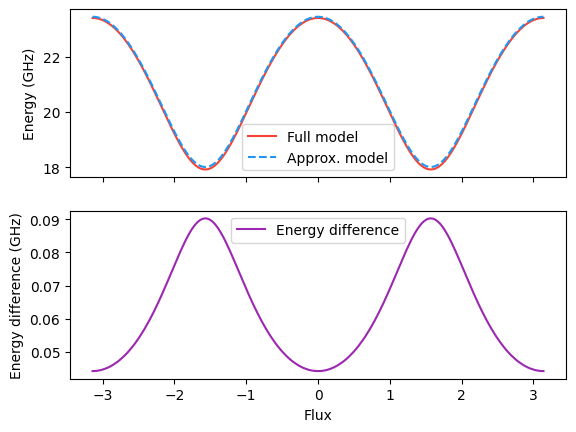

In [11]:
state = 4

exact_energies = exact_evals[:, state]
approx_energies = approx_evals[:, state]

fig, (comp_ax, diff_ax) = plt.subplots(nrows=2, sharex=True)

comp_ax.plot(fluxes, exact_energies, color="#f44336", label=f"Full model")
comp_ax.plot(
    fluxes, approx_energies, color="#2196f3", linestyle="--", label=f"Approx. model"
)

comp_ax.legend()
comp_ax.set_ylabel("Energy (GHz)")


energy_diff = np.abs(exact_energies - approx_energies)
diff_ax.plot(fluxes, energy_diff, color="#9c27b0", label=f"Energy difference")

diff_ax.legend()
diff_ax.set_xlabel("Flux")
diff_ax.set_ylabel("Energy difference (GHz)")

plt.show()

# Flux scan using the flux drive

In [12]:
num_points = 201
flux_bound = math.pi
fluxes = np.linspace(-flux_bound, flux_bound, num_points)

In [13]:
charge_dim = 2 * CHARGE_CUTOFF + 1
exact_drive_evals = np.zeros((num_points, charge_dim))

fluxed_transmon = TunableTransmon(
    label=LABEL,
    charging_energy=CHARGING_ENERGY,
    josephson_energy=JOSEPHSON_ENERGY,
    offset_charge=OFFSET_CHARGE,
    ext_flux=EXT_FLUX,
    asymmetry=ASYMMETRY,
    charge_cutoff=CHARGE_CUTOFF,
)
static_hamiltonian = fluxed_transmon.get_hamiltonian()

fluxed_transmon.add_flux_drive("flux_drive", flux_pulse)

for ind, flux in enumerate(fluxes):
    drive_hamiltonian = fluxed_transmon.get_drive_hamiltonian(applied_flux=flux)
    full_hamiltonian = static_hamiltonian + drive_hamiltonian
    energies = jsp.linalg.eigh(full_hamiltonian, eigvals_only=True)
    norm_energies = energies - energies[0]
    exact_drive_evals[ind] = norm_energies

In [14]:
dim = 6
approx_drive_evals = np.zeros((num_points, dim))

fluxed_transmon = KerrOscillator(
    label=LABEL,
    frequency=FREQUENCY,
    anharmonicity=ANHARMONICITY,
    ext_flux=EXT_FLUX,
    asymmetry=ASYMMETRY,
    dim=dim,
)

static_hamiltonian = fluxed_transmon.get_hamiltonian()

fluxed_transmon.add_flux_drive("flux_drive", flux_pulse)

for ind, flux in enumerate(fluxes):
    drive_hamiltonian = fluxed_transmon.get_drive_hamiltonian(applied_flux=flux)
    full_hamiltonian = static_hamiltonian + drive_hamiltonian
    energies = jsp.linalg.eigh(full_hamiltonian, eigvals_only=True)
    norm_energies = energies - energies[0]
    approx_drive_evals[ind] = norm_energies

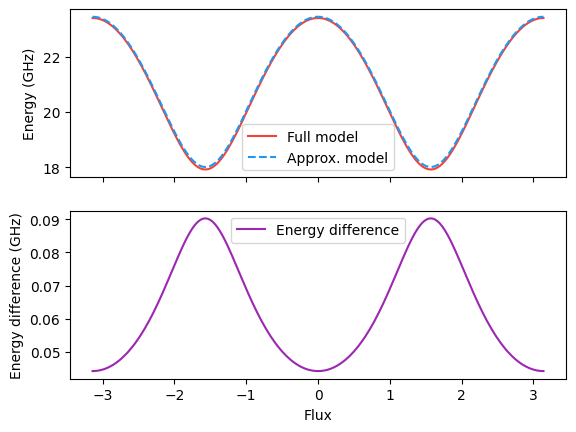

In [15]:
state = 4

exact_energies = exact_drive_evals[:, state]
approx_energies = approx_drive_evals[:, state]

fig, (comp_ax, diff_ax) = plt.subplots(nrows=2, sharex=True)

comp_ax.plot(fluxes, exact_energies, color="#f44336", label=f"Full model")
comp_ax.plot(
    fluxes, approx_energies, color="#2196f3", linestyle="--", label=f"Approx. model"
)

comp_ax.legend()
comp_ax.set_ylabel("Energy (GHz)")


energy_diff = np.abs(exact_energies - approx_energies)
diff_ax.plot(fluxes, energy_diff, color="#9c27b0", label=f"Energy difference")

diff_ax.legend()
diff_ax.set_xlabel("Flux")
diff_ax.set_ylabel("Energy difference (GHz)")

plt.show()

# Test energy difference for the Net-zero flux pulse

In [16]:
num_points = 201
times = np.linspace(0, 100, num_points)

In [17]:
charge_dim = 2 * CHARGE_CUTOFF + 1
exact_drive_evals = np.zeros((num_points, charge_dim))

fluxed_transmon = TunableTransmon(
    label=LABEL,
    charging_energy=CHARGING_ENERGY,
    josephson_energy=JOSEPHSON_ENERGY,
    offset_charge=OFFSET_CHARGE,
    ext_flux=EXT_FLUX,
    asymmetry=ASYMMETRY,
    charge_cutoff=CHARGE_CUTOFF,
)
static_hamiltonian = fluxed_transmon.get_hamiltonian()

fluxed_transmon.add_flux_drive("flux_drive", net_zero_transition_flux_pulse)
fluxed_transmon.drives["flux_drive"].set_params(
    hold_first_voltage=-0.255,
    transition_voltage=0.0,
    half_hold_time=65.15 * 0.5,
    transition_time=2.414131062723352,
    buffer_start=1.9349107142857144e1,
    buffer_end=1.9349107142857144e1,
    flux_per_volt=3.1372549019607843,
    gaussian_filter_sigma=0.5,
)

for ind, time in enumerate(times):
    drive_hamiltonian = fluxed_transmon.get_drive_hamiltonian(t=time)
    full_hamiltonian = static_hamiltonian + drive_hamiltonian
    energies = jsp.linalg.eigh(full_hamiltonian, eigvals_only=True)
    norm_energies = energies - energies[0]
    exact_drive_evals[ind] = norm_energies

In [18]:
dim = 6
approx_drive_evals = np.zeros((num_points, dim))

fluxed_transmon = KerrOscillator(
    label=LABEL,
    frequency=FREQUENCY,
    anharmonicity=ANHARMONICITY,
    ext_flux=EXT_FLUX,
    asymmetry=ASYMMETRY,
    dim=dim,
)

static_hamiltonian = fluxed_transmon.get_hamiltonian()

fluxed_transmon.add_flux_drive("flux_drive", net_zero_transition_flux_pulse)
fluxed_transmon.drives["flux_drive"].set_params(
    hold_first_voltage=-0.255,
    transition_voltage=0.0,
    half_hold_time=65.15 * 0.5,
    transition_time=2.414131062723352,
    buffer_start=1.9349107142857144e1,
    buffer_end=1.9349107142857144e1,
    flux_per_volt=3.1372549019607843,
    gaussian_filter_sigma=0.5,
)

for ind, time in enumerate(times):
    drive_hamiltonian = fluxed_transmon.get_drive_hamiltonian(t=time)
    full_hamiltonian = static_hamiltonian + drive_hamiltonian
    energies = jsp.linalg.eigh(full_hamiltonian, eigvals_only=True)
    norm_energies = energies - energies[0]
    approx_drive_evals[ind] = norm_energies

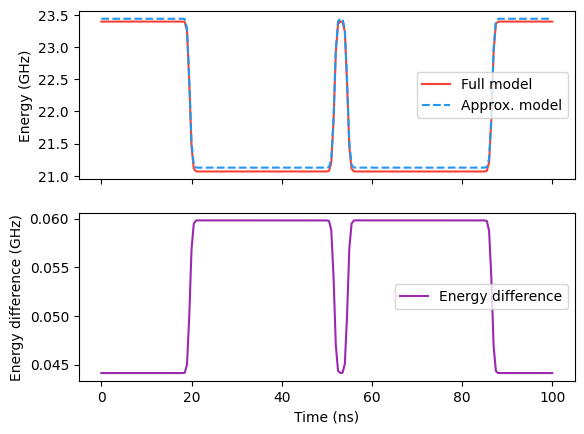

In [19]:
state = 4

exact_energies = exact_drive_evals[:, state]
approx_energies = approx_drive_evals[:, state]

fig, (comp_ax, diff_ax) = plt.subplots(nrows=2, sharex=True)

comp_ax.plot(times, exact_energies, color="#f44336", label=f"Full model")
comp_ax.plot(
    times, approx_energies, color="#2196f3", linestyle="--", label=f"Approx. model"
)

comp_ax.legend()
comp_ax.set_ylabel("Energy (GHz)")


energy_diff = np.abs(exact_energies - approx_energies)
diff_ax.plot(times, energy_diff, color="#9c27b0", label=f"Energy difference")

diff_ax.legend()
diff_ax.set_xlabel("Time (ns)")
diff_ax.set_ylabel("Energy difference (GHz)")

plt.show()

In [26]:
for prefactor, op in fluxed_transmon.get_drive_hamiltonian_terms():
    print(prefactor)
    res = prefactor(0.1)

functools.partial(<function net_zero_transition_flux_pulse at 0x119bcaa20>, hold_first_voltage=-0.255, transition_voltage=0.0, half_hold_time=32.575, transition_time=2.414131062723352, buffer_start=19.349107142857143, buffer_end=19.349107142857143, flux_per_volt=3.1372549019607843, gaussian_filter_sigma=0.5)
